In [2]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 696.5/696.5 kB 41.9 MB/s eta 0:00:00


In [4]:
!pip install opensignalsreader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.2 MB/s eta 0:00:00


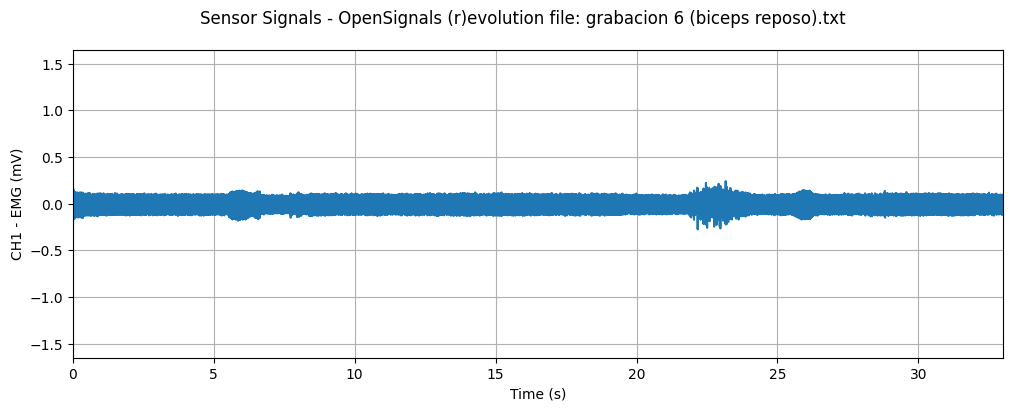

Variable            Type                 Data/Info
--------------------------------------------------
OpenSignalsReader   type                 <class 'opensignalsreader<...>eader.OpenSignalsReader'>
acq                 OpenSignalsReader    <opensignalsreader.opensi<...>object at 0x78cb9b9db890>
display             function             <function display at 0x78cbf83a5ee0>
get_ipython         function             <function get_ipython at 0x78cbf85eb560>
nk                  module               <module 'neurokit2' from <...>s/neurokit2/__init__.py'>
pd                  module               <module 'pandas' from '/u<...>ages/pandas/__init__.py'>


In [7]:
!pip install neurokit2
!pip install opensignalsreader # Install the missing library
from IPython import get_ipython
from IPython.display import display
# %%
import pandas as pd
import neurokit2 as nk
from opensignalsreader import OpenSignalsReader
acq = OpenSignalsReader('grabacion 6 (biceps reposo).txt',show="True")
#emg_signal = acq.signal()['EMG']
#signals, info = nk.emg_process(emg_signal, sampling_rate=1000)
#nk.emg_plot(signals, info)
# %%
%whos

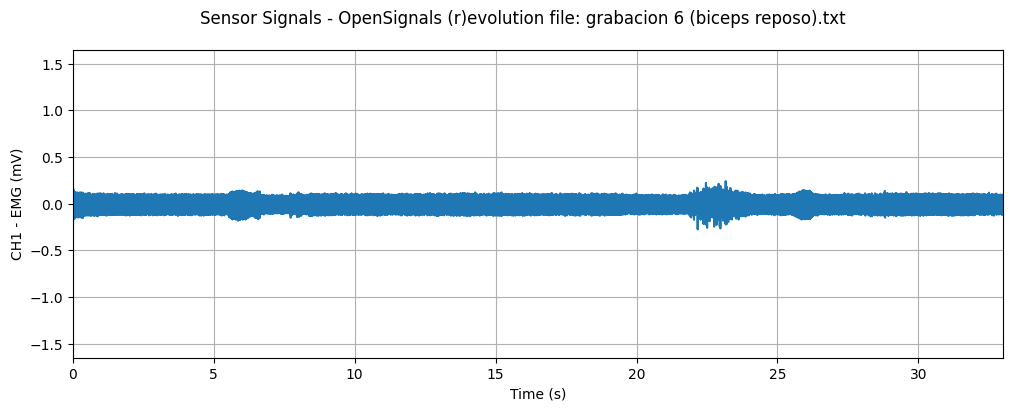

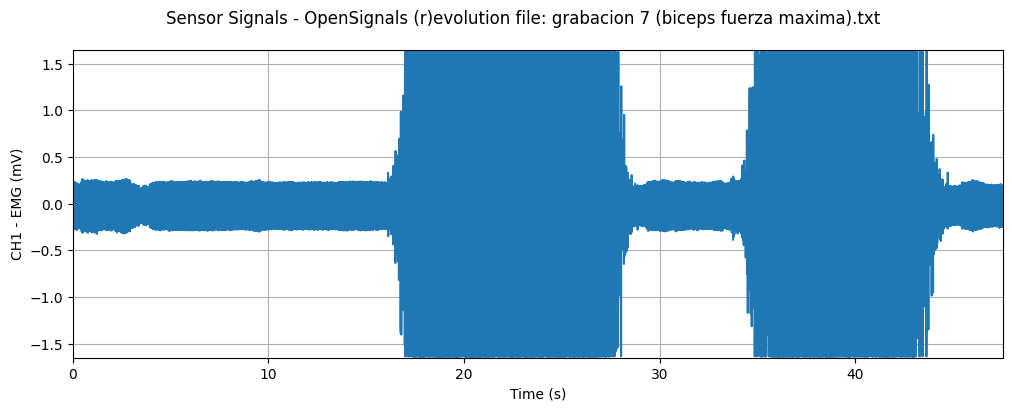

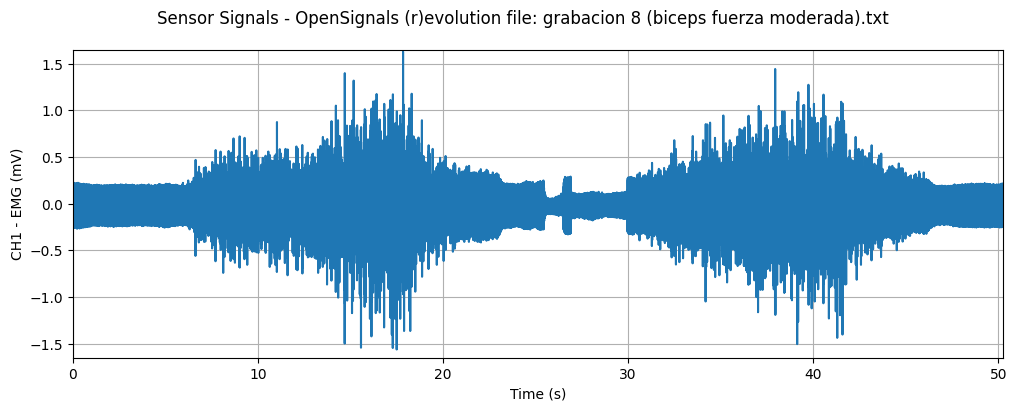

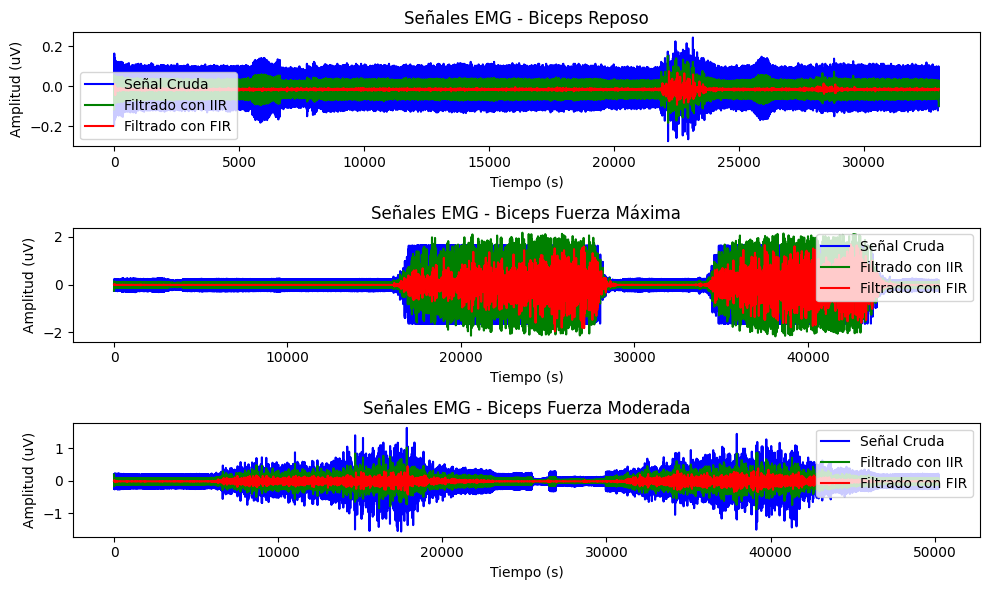

In [11]:
!pip install neurokit2
!pip install opensignalsreader

from IPython import get_ipython
from IPython.display import display
import pandas as pd
import neurokit2 as nk
from opensignalsreader import OpenSignalsReader
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, firwin, lfilter
import os # Import the os module

# Cargar los datos
acq_reposo = OpenSignalsReader('grabacion 6 (biceps reposo).txt', show="True")
acq_fuerza_maxima = OpenSignalsReader('grabacion 7 (biceps fuerza maxima).txt', show="True")
acq_fuerza_moderada = OpenSignalsReader('grabacion 8 (biceps fuerza moderada).txt', show="True")

# señales EMG
emg_reposo = acq_reposo.signal()['EMG']
emg_fuerza_maxima = acq_fuerza_maxima.signal()['EMG']
emg_fuerza_moderada = acq_fuerza_moderada.signal()['EMG']

#filtros
fs = 1000  # Frecuencia de muestreo en Hz
cutoff_iir = 60  # Frecuencia de corte para filtro IIR (Hz)
cutoff_fir = 40  # Frecuencia de corte para filtro FIR (Hz)

#filtro Butterworth (IIR)
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order)
    return filtfilt(b, a, data)

# filtro FIR
def fir_filter(data, cutoff, fs, numtaps=101):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    taps = firwin(numtaps, normal_cutoff, pass_zero='lowpass')
    return lfilter(taps, 1.0, data)

# filtros IIR y FIR
filtered_reposo_iir = butter_filter(emg_reposo, cutoff_iir, fs)
filtered_fuerza_maxima_iir = butter_filter(emg_fuerza_maxima, cutoff_iir, fs)
filtered_fuerza_moderada_iir = butter_filter(emg_fuerza_moderada, cutoff_iir, fs)

filtered_reposo_fir = fir_filter(emg_reposo, cutoff_fir, fs)
filtered_fuerza_maxima_fir = fir_filter(emg_fuerza_maxima, cutoff_fir, fs)
filtered_fuerza_moderada_fir = fir_filter(emg_fuerza_moderada, cutoff_fir, fs)

# tabla resumen
summary_table = pd.DataFrame({
    'Campo de actividad': ['Descanso', 'Contracción leve', 'Contracción fuerte'],
    'Señal cruda': [emg_reposo[:5], emg_fuerza_maxima[:5], emg_fuerza_moderada[:5]],  # Primeras 5 muestras
    'Señal filtrada con filtro IIR': [filtered_reposo_iir[:5], filtered_fuerza_maxima_iir[:5], filtered_fuerza_moderada_iir[:5]],
    'Señal filtrada con filtro FIR': [filtered_reposo_fir[:5], filtered_fuerza_maxima_fir[:5], filtered_fuerza_moderada_fir[:5]],
})

# Define the directory path
output_directory = '/mnt/data'
# Create the directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# Define the full file path
csv_filepath = os.path.join(output_directory, 'tabla_resumen.csv')

# Guardar la tabla en un archivo CSV
summary_table.to_csv(csv_filepath, index=False)

# Crear los gráficos para comparar las señales
plt.figure(figsize=(10, 6))

# Gráfico para "Biceps Reposo"
plt.subplot(3, 1, 1)
plt.plot(emg_reposo, label='Señal Cruda', color='blue')
plt.plot(filtered_reposo_iir, label='Filtrado con IIR', color='green')
plt.plot(filtered_reposo_fir, label='Filtrado con FIR', color='red')
plt.title('Señales EMG - Biceps Reposo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.legend()

# Gráfico para "Biceps Fuerza Máxima"
plt.subplot(3, 1, 2)
plt.plot(emg_fuerza_maxima, label='Señal Cruda', color='blue')
plt.plot(filtered_fuerza_maxima_iir, label='Filtrado con IIR', color='green')
plt.plot(filtered_fuerza_maxima_fir, label='Filtrado con FIR', color='red')
plt.title('Señales EMG - Biceps Fuerza Máxima')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.legend()

# Gráfico para "Biceps Fuerza Moderada"
plt.subplot(3, 1, 3)
plt.plot(emg_fuerza_moderada, label='Señal Cruda', color='blue')
plt.plot(filtered_fuerza_moderada_iir, label='Filtrado con IIR', color='green')
plt.plot(filtered_fuerza_moderada_fir, label='Filtrado con FIR', color='red')
plt.title('Señales EMG - Biceps Fuerza Moderada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (uV)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
%whos

Variable            Type                 Data/Info
--------------------------------------------------
OpenSignalsReader   type                 <class 'opensignalsreader<...>eader.OpenSignalsReader'>
acq                 OpenSignalsReader    <opensignalsreader.opensi<...>ct at 0x0000019ADC23A890>
emg_signal          ndarray              42000: 42000 elems, type `float64`, 336000 bytes (328.125 kb)
info                dict                 n=4
nk                  module               <module 'neurokit2' from <...>\neurokit2\\__init__.py'>
pd                  module               <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
signals             DataFrame                    EMG_Raw  EMG_Clea<...>n[42000 rows x 6 columns]
